## Author: Gabriel Vance
## Class: DSC640 - Data Presentation & Visualization 
## Professor: Benjamin Schneider
## Date: September 20, 2025

# Purpose: This notebook performs the tasks for Week 1 & 2 assignment.

In [78]:

# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Ensure that all code cells are fully visible without scrolling
from IPython.core.display import display, HTML

display(HTML('''
<style>
div.CodeMirror pre {
    white-space: pre !important;
}
</style>
'''))


In [79]:
# Read in the Excel files
all_weeks_countries_netflix = pd.read_excel('all-weeks-countries-netflix.xlsx')
all_weeks_global_netflix = pd.read_excel('all-weeks-global-netflix.xlsx')
most_popular_netflix = pd.read_excel('most-popular-netflix.xlsx')

In [80]:
# Save sample files to better understand data

all_weeks_countries_netflix.sample(30).to_csv('all_weeks_countries_netflix_sample.csv', index=False)
all_weeks_global_netflix.sample(30).to_csv('all_weeks_global_netflix_sample.csv', index=False)
most_popular_netflix.sample(30).to_csv('most_popular_netflix_sample.csv', index=False)

In [81]:
# Unique values in category column
print(all_weeks_global_netflix['category'].unique())

['Films (English)' 'Films (Non-English)' 'TV (English)' 'TV (Non-English)']


In [82]:
# Gather summary statistics for weekly_hours_viewed by category
category_sums = all_weeks_global_netflix.groupby('category')['weekly_hours_viewed'].sum()
print(category_sums)

category
Films (English)        22069420000
Films (Non-English)     9680460000
TV (English)           46591630000
TV (Non-English)       29740210000
Name: weekly_hours_viewed, dtype: int64


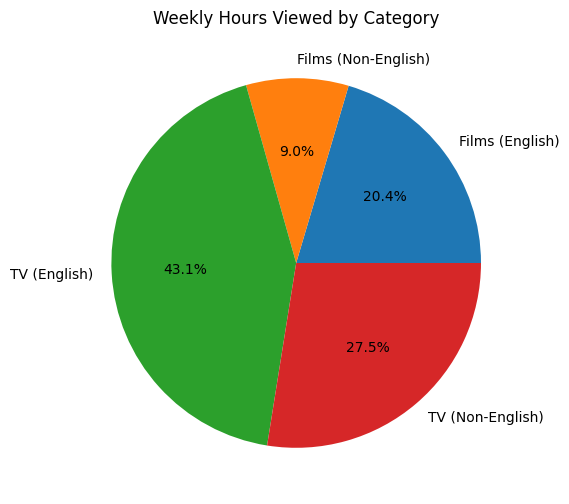

In [83]:
# Plot pie chart of weekly_hours_viewed by category
category_sums.plot.pie(autopct='%1.1f%%', figsize=(6, 6), ylabel='', title='Weekly Hours Viewed by Category')
plt.show()

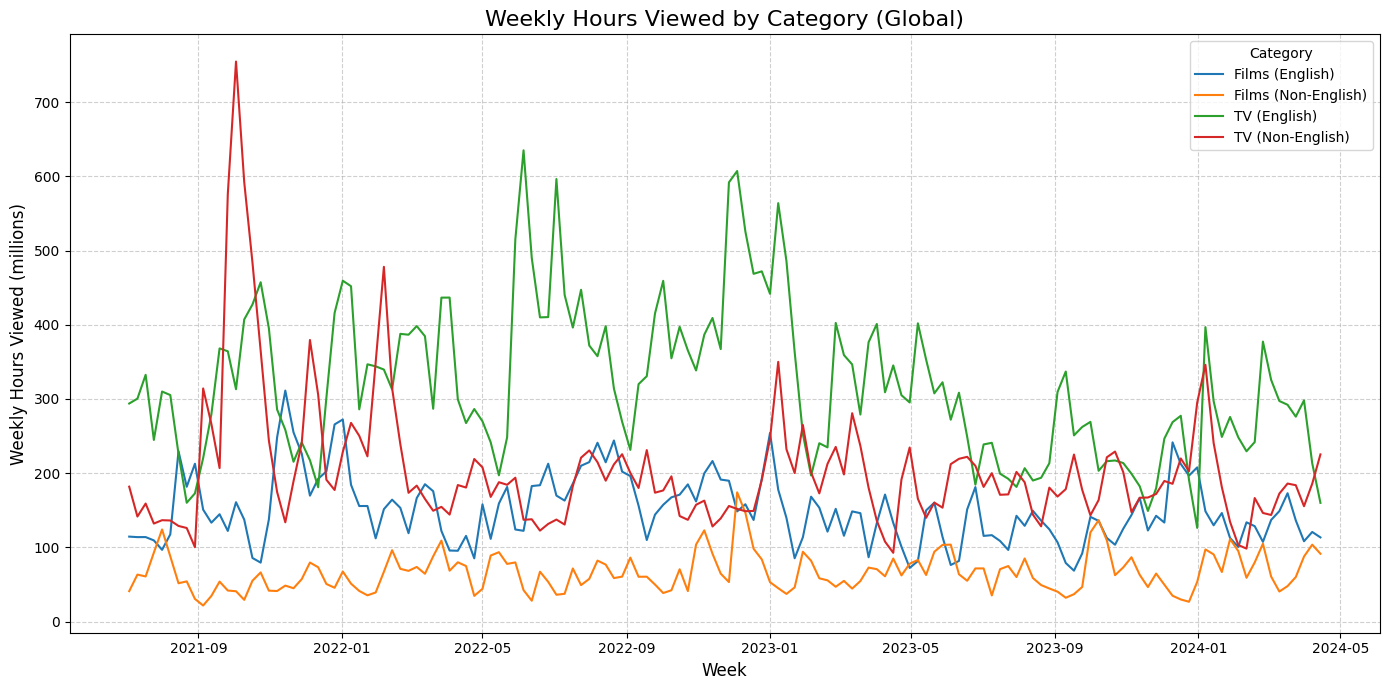

In [84]:
# Convert week to datetime
all_weeks_global_netflix["week"] = pd.to_datetime(all_weeks_global_netflix["week"], errors="coerce")

# Group by week and category, summing hours viewed
weekly_trends = (
    all_weeks_global_netflix.groupby(["week", "category"])["weekly_hours_viewed"]
    .sum()
    .reset_index()
)

# Pivot for plotting
pivot_trends = weekly_trends.pivot(index="week", columns="category", values="weekly_hours_viewed")

# Convert to millions for better readability
pivot_trends_millions = pivot_trends / 1e6

plt.figure(figsize=(14, 7))
for col in pivot_trends_millions.columns:
    plt.plot(pivot_trends_millions.index, pivot_trends_millions[col], label=col)

plt.title("Weekly Hours Viewed by Category (Global)", fontsize=16)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Weekly Hours Viewed (millions)", fontsize=12)
plt.legend(title="Category")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


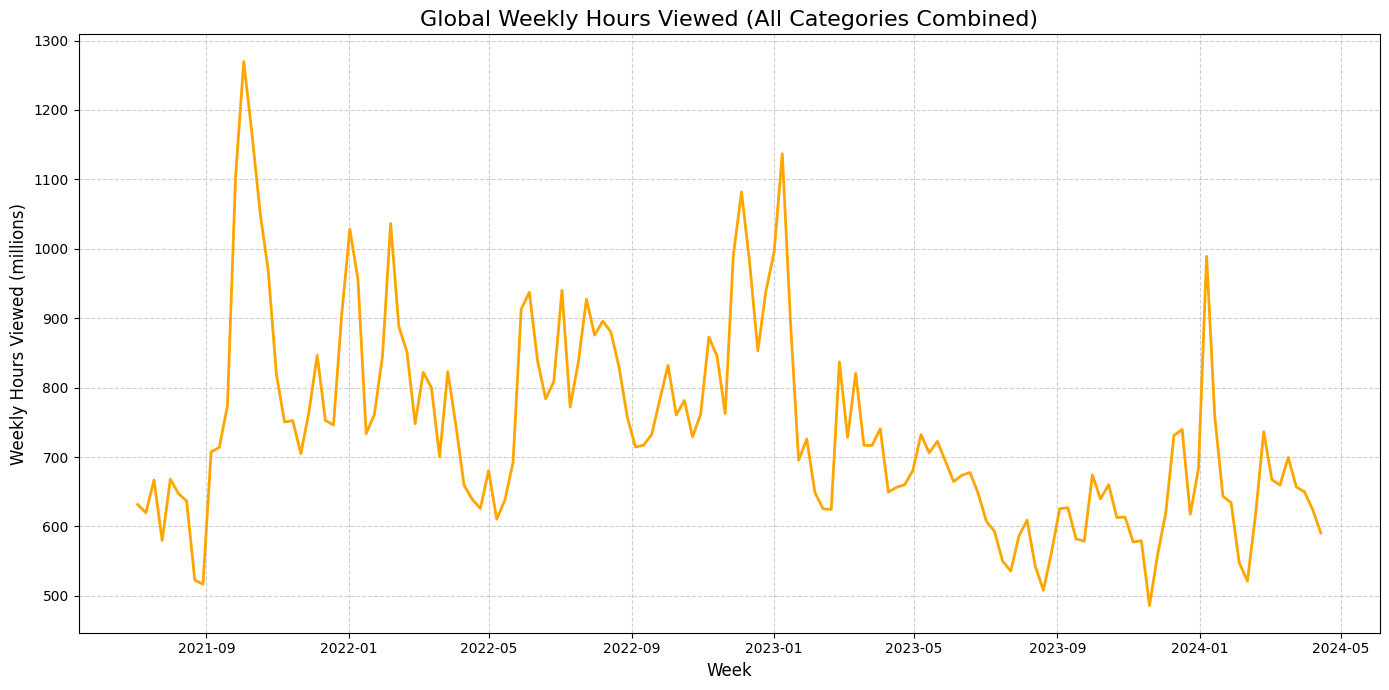

In [85]:
# Convert week to datetime (note, this is redundant if run in same session)
all_weeks_global_netflix["week"] = pd.to_datetime(all_weeks_global_netflix["week"], errors="coerce")

# Group by week only, summing across all categories
weekly_trends = (
    all_weeks_global_netflix.groupby("week")["weekly_hours_viewed"]
    .sum()
    .reset_index()
)

# Convert to millions for better readability
weekly_trends["weekly_hours_viewed_millions"] = weekly_trends["weekly_hours_viewed"] / 1e6

# Plot overall trend
plt.figure(figsize=(14, 7))
plt.plot(
    weekly_trends["week"],
    weekly_trends["weekly_hours_viewed_millions"],
    color="orange",
    linewidth=2,
)

plt.title("Global Weekly Hours Viewed (All Categories Combined)", fontsize=16)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Weekly Hours Viewed (millions)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


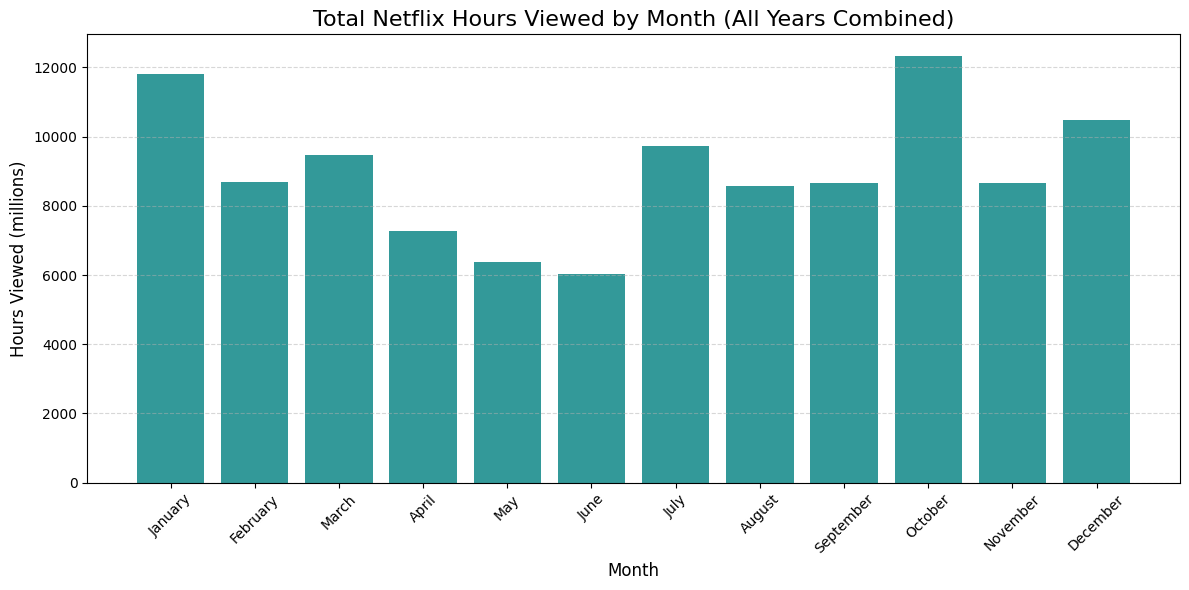

In [86]:
# Ensure week column is datetime
all_weeks_global_netflix["week"] = pd.to_datetime(all_weeks_global_netflix["week"], errors="coerce")

# Extract month number and name
all_weeks_global_netflix["month_num"] = all_weeks_global_netflix["week"].dt.month
all_weeks_global_netflix["month_name"] = all_weeks_global_netflix["week"].dt.month_name()

# Group by month number (to keep correct order), summing across all years
monthly_trends = (
    all_weeks_global_netflix.groupby(["month_num", "month_name"])["weekly_hours_viewed"]
    .sum()
    .reset_index()
    .sort_values("month_num")
)

# Convert to millions
monthly_trends["views_millions"] = monthly_trends["weekly_hours_viewed"] / 1e6

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(monthly_trends["month_name"], monthly_trends["views_millions"], color="teal", alpha=0.8)

plt.title("Total Netflix Hours Viewed by Month (All Years Combined)", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Hours Viewed (millions)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5, axis="y")
plt.tight_layout()
plt.show()


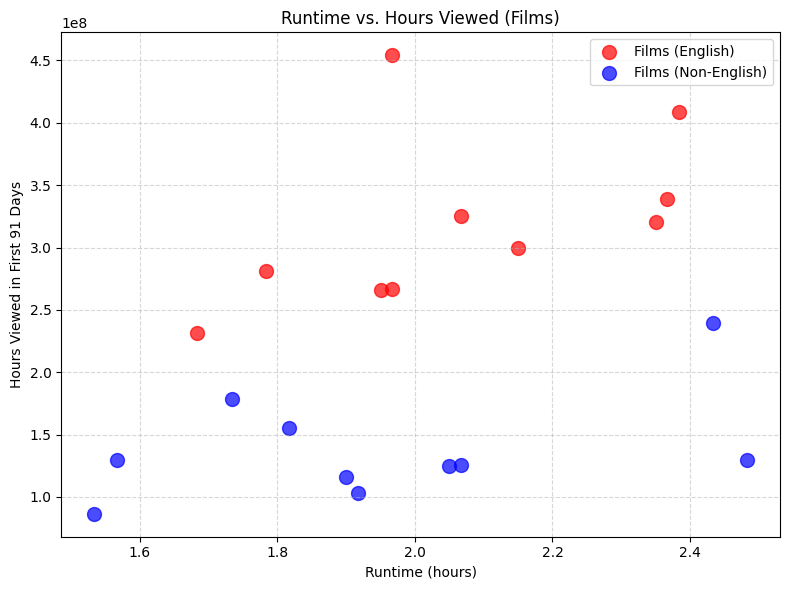

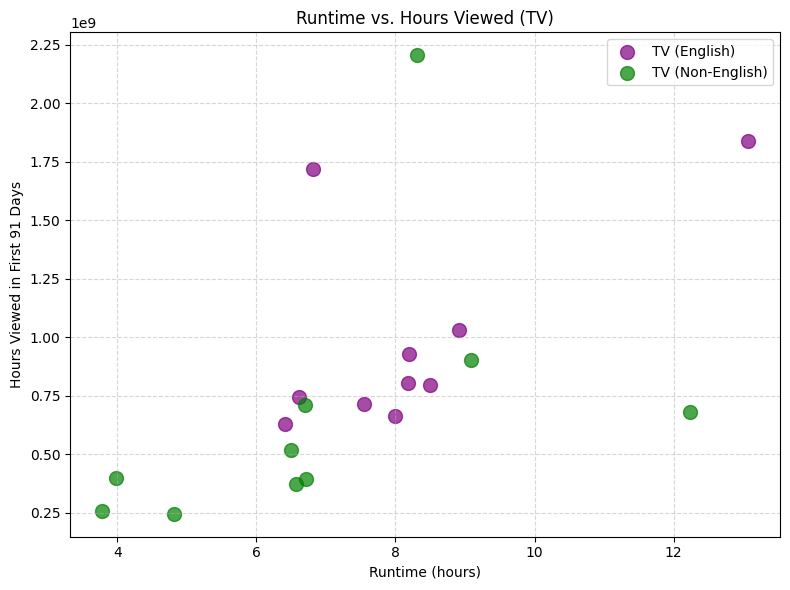

In [87]:

# Scatter plot for Films (English) and Films (Non-English)
films_df = most_popular_netflix[most_popular_netflix['category'].isin(['Films (English)', 'Films (Non-English)'])]

plt.figure(figsize=(8, 6))
for cat, color in zip(['Films (English)', 'Films (Non-English)'], ['red', 'blue']):
    subset = films_df[films_df['category'] == cat]
    plt.scatter(subset['runtime'], subset['hours_viewed_first_91_days'], alpha=0.7, label=cat, color=color, s=100)
plt.xlabel('Runtime (hours)')
plt.ylabel('Hours Viewed in First 91 Days')
plt.title('Runtime vs. Hours Viewed (Films)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Scatter plot for TV (English) and TV (Non-English)
tv_df = most_popular_netflix[most_popular_netflix['category'].isin(['TV (English)', 'TV (Non-English)'])]

plt.figure(figsize=(8, 6))
for cat, color in zip(['TV (English)', 'TV (Non-English)'], ['purple', 'green']):
    subset = tv_df[tv_df['category'] == cat]
    plt.scatter(subset['runtime'], subset['hours_viewed_first_91_days'], alpha=0.7, label=cat, color=color, s=100)
plt.xlabel('Runtime (hours)')
plt.ylabel('Hours Viewed in First 91 Days')
plt.title('Runtime vs. Hours Viewed (TV)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

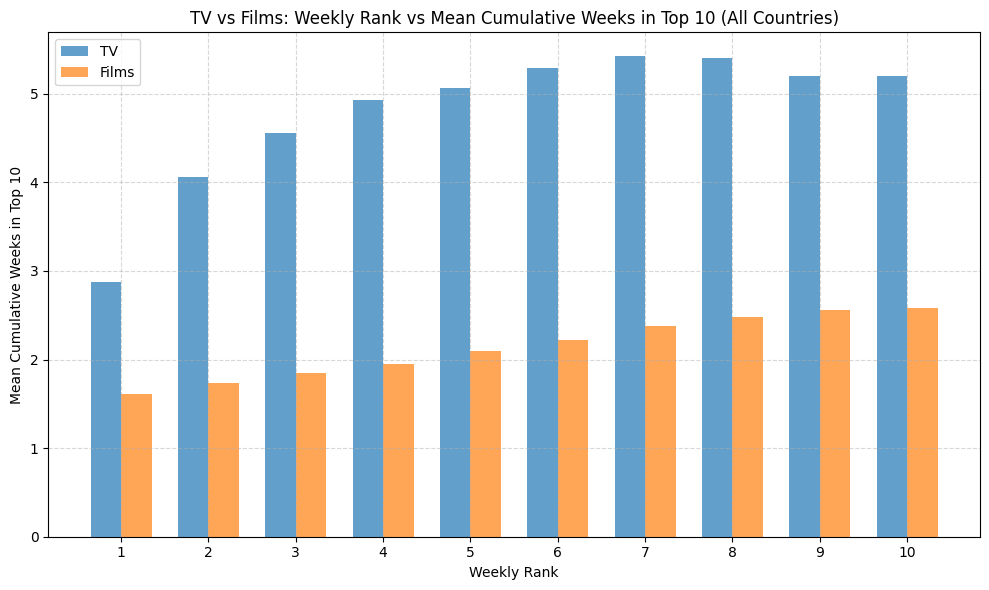

In [88]:
# Filter for TV and Films only
subset_df = all_weeks_countries_netflix[all_weeks_countries_netflix['category'].isin(['TV', 'Films'])]

# Group by category and weekly_rank, then calculate mean cumulative_weeks_in_top_10
rank_means = (
    subset_df.groupby(['category', 'weekly_rank'])['cumulative_weeks_in_top_10']
    .mean()
    .reset_index()
)

# Pivot so categories become columns
rank_pivot = rank_means.pivot(index='weekly_rank', columns='category', values='cumulative_weeks_in_top_10')

# Plot
plt.figure(figsize=(10, 6))
width = 0.35
x = rank_pivot.index

plt.bar(x - width/2, rank_pivot['TV'], width=width, label='TV', alpha=0.7)
plt.bar(x + width/2, rank_pivot['Films'], width=width, label='Films', alpha=0.7)

plt.xlabel('Weekly Rank')
plt.ylabel('Mean Cumulative Weeks in Top 10')
plt.title('TV vs Films: Weekly Rank vs Mean Cumulative Weeks in Top 10 (All Countries)')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Purpose/Call to Arms - Netflix must prioritize TV shows over movies to maintain viewership or it will lose its competitive edge. Additionally, it should seek out longevity over "hot flashes in the pan" to maintain a steady viewership, aiming for 7-9 hours of runtime per TV show.

# Target audience - Netflix Management Team (C-Suite, Directors, Managers). They need to make the moves recommended by our team, namely budget/resource reallocation to TV shows over movies, and a focus on longevity of content over "hot flashes in the pan".

# Medium - A PDF report with embedded visualizations. The short report format is appropriate for busy executives who need to quickly grasp the insights and recommendations.

### Netflix once began was the only streaming service. Competition has increase in recent years, and Netflix's survival is at stake. The streaming war is won by content, and Netflix has to prioritize the content that maintains higher consistent viewership.

### Our data science division has analyzed the viewership data and provided insights to management. Overall viewership is 43% English TV, 28% Non-English TV and 29% films. TV shows account for 71% of viewership, so they are our highest priority. Our budgeting departing should prioritize that 70 cents on every dollar in the content budget is spent on TV shows.

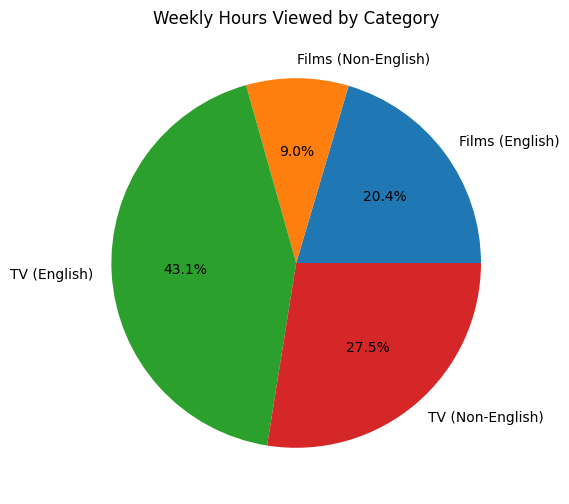

### While we found success in shows like Squid Games, we found that these shows are "hot flashes in the pan" and do not maintain viewership. You can clearly see the red spike after September 2021, but then the viewership drops off quickly. We cannot chase hits as they are not sustainable. We need to find shows that have longevity and maintain viewership over time. 

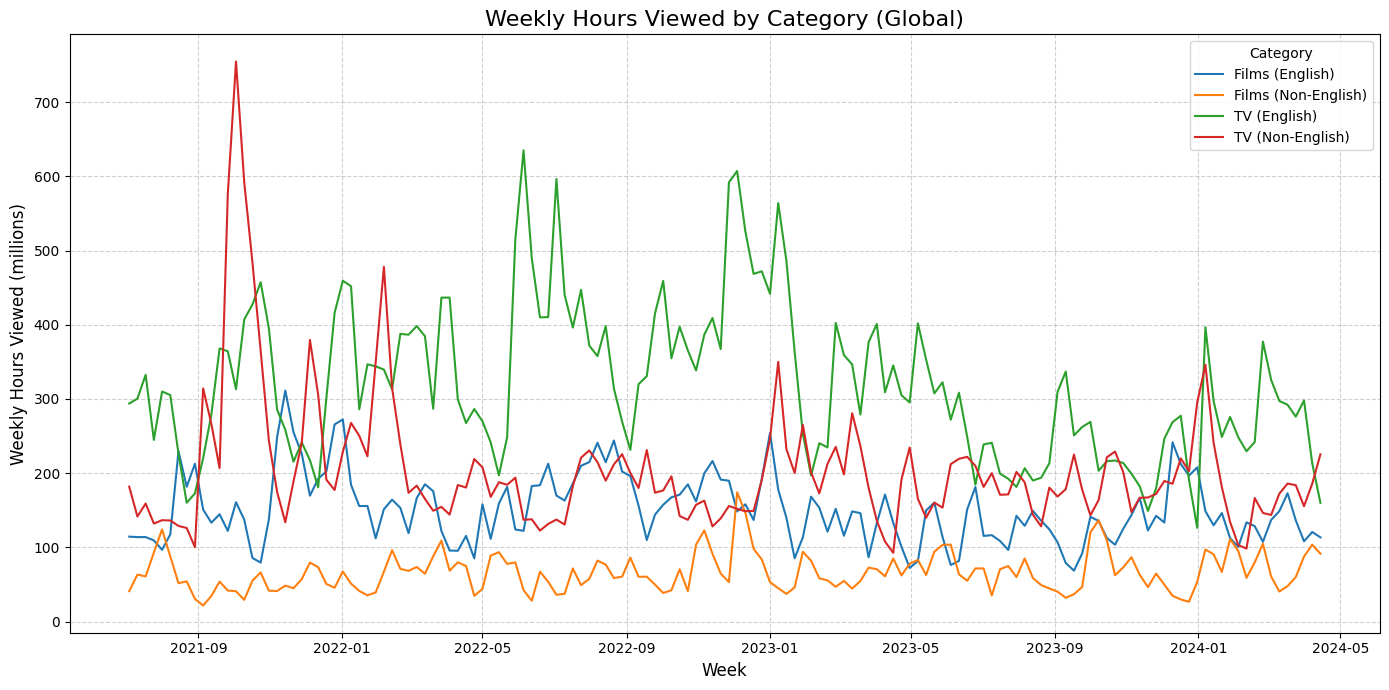

### In fact, these anomalies skew data. Truth is, our viewership was higher in 2022 and has steadily been declining through 2023 and 2024.

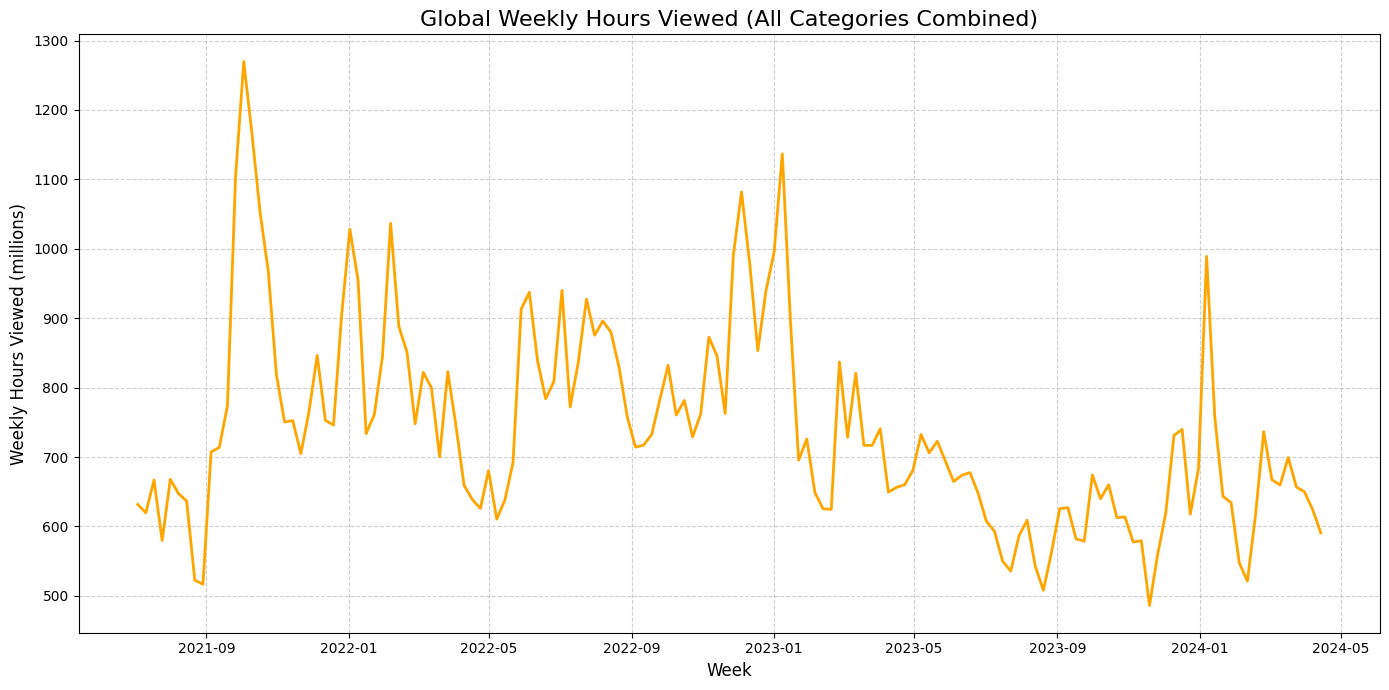

### For both English and Non-English TV, we found that an average runtime between 7 and 9 hours had consistent viewership within the first 91 days. Note the green and purple cluster.

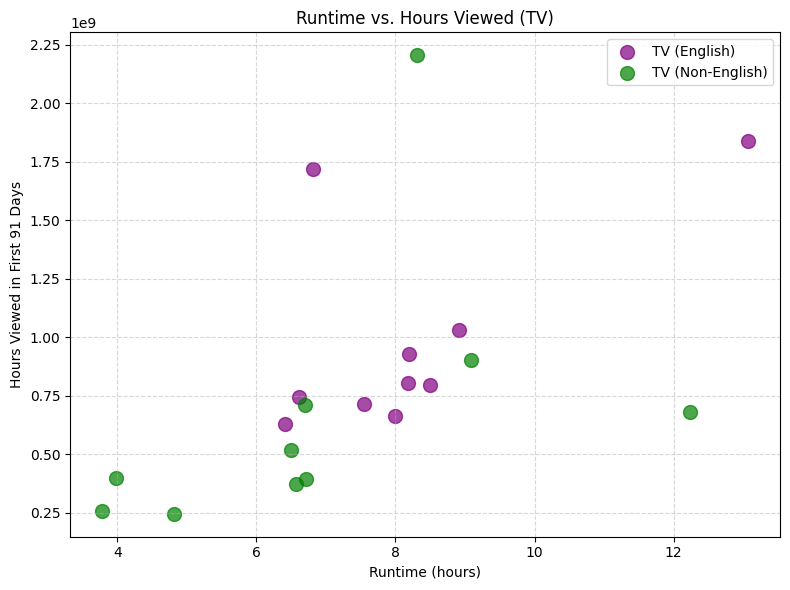

## In summary: Netflix must prioritize TV shows over movies to maintain viewership. Additionally, it should seek out longevity over "hot flashes in the pan" to maintain a steady viewership. TV shows should be within 7-9 hours of runtime to maintain viewership.